<a href="https://colab.research.google.com/github/suryanshshah2006/complete-triplet-bilstm-sleep-staging/blob/main/Zan_EEG_Sleep_Stage_Classification(EpochSplit).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install scipy scikit-learn seaborn
from google.colab import drive
drive.mount('/content/drive')

import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tqdm.notebook import tqdm
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
import seaborn as sns
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
SOURCE_DIR = '/content/drive/MyDrive/EEG_Full_58_Subjects'
MASTER_CSV = '/content/drive/MyDrive/EEG_Full_58_Subjects/master_labels_clean.csv'
LOCAL_DIR = '/content/local_eeg_data'
MODEL_DIR = '/content/drive/MyDrive/eeg_bilstm_complete_triplets'
os.makedirs(MODEL_DIR, exist_ok=True)
CLASS_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
SPLIT_COL = 'split_epoch_level'   # this notebook = epoch-level only

In [ ]:
if not os.path.exists(LOCAL_DIR):
    print("Unzipping calibrated data into Colab local runtime...")
    shutil.unpack_archive('/content/drive/MyDrive/Zan_EEG_128Hz_Epochs_CALIBRATED.zip', LOCAL_DIR)
    print("Local data restored!")

print("Building subject-wise epoch indexer...")

labels_df = pd.read_csv(MASTER_CSV)
labels_df = labels_df[['subject', 'seg_idx', 'label', 'label_code', 'exists']]

files = [f for f in os.listdir(LOCAL_DIR) if f.endswith('.npy')]
file_df = pd.DataFrame({'filename': files})
file_df['subject'] = file_df['filename'].apply(lambda x: x.split('_seg_')[0])
file_df['seg_idx'] = file_df['filename'].apply(lambda x: int(x.split('_seg_')[1].replace('.npy', '')))
file_df['filepath'] = os.path.join(LOCAL_DIR, '') + file_df['filename']

master_df = pd.merge(file_df, labels_df, on=['subject', 'seg_idx'], how='inner')
master_df = master_df.sort_values(by=['subject', 'seg_idx']).reset_index(drop=True)

print("Rows:", len(master_df))
print("Subjects:", master_df['subject'].nunique())

sample_arr = np.load(master_df.iloc[0]['filepath'])
EPOCH_LEN = sample_arr.shape[1]
N_CHANNELS = sample_arr.shape[0]
print(f"Detected shape: {N_CHANNELS} channels x {EPOCH_LEN} samples")

Building subject-wise epoch indexer...
Rows: 47090
Subjects: 52
Detected shape: 24 channels x 3840 samples


In [ ]:
master_df['epoch_rank'] = master_df.groupby('subject').cumcount()

train_e_idx, val_e_idx = train_test_split(
    master_df.index, test_size=0.2, random_state=42, stratify=master_df['label_code']
)
master_df['split_epoch_level'] = 'train'
master_df.loc[val_e_idx, 'split_epoch_level'] = 'val'

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_s_idx, val_s_idx = next(gss.split(master_df, groups=master_df['subject']))
master_df['split_subject_level'] = 'train'
master_df.loc[val_s_idx, 'split_subject_level'] = 'val'

print(f"[{SPLIT_COL}] Train: {(master_df[SPLIT_COL]=='train').sum()}  Val: {(master_df[SPLIT_COL]=='val').sum()}")

[split_epoch_level] Train: 37672  Val: 9418


In [ ]:
lookup = master_df.set_index(['subject', 'epoch_rank'])
triplet_rows = []
for _, row in master_df.iterrows():
    sub, rank = row['subject'], int(row['epoch_rank'])
    try:
        prev_row = lookup.loc[(sub, rank - 1)]
        curr_row = lookup.loc[(sub, rank)]
        next_row = lookup.loc[(sub, rank + 1)]
        if isinstance(prev_row, pd.DataFrame): prev_row = prev_row.iloc[0]
        if isinstance(curr_row, pd.DataFrame): curr_row = curr_row.iloc[0]
        if isinstance(next_row, pd.DataFrame): next_row = next_row.iloc[0]
        if not (int(prev_row['seg_idx']) + 1 == int(curr_row['seg_idx']) and
                int(curr_row['seg_idx']) + 1 == int(next_row['seg_idx'])):
            continue
        triplet_rows.append({
            'subject': sub, 'epoch_rank': rank, 'seg_idx': int(curr_row['seg_idx']),
            'filepath_prev': prev_row['filepath'], 'filepath_curr': curr_row['filepath'],
            'filepath_next': next_row['filepath'],
            'label_code': int(curr_row['label_code']),
            'split_epoch_level': curr_row['split_epoch_level'],
            'split_subject_level': curr_row['split_subject_level'],
        })
    except KeyError:
        continue

triplet_df = pd.DataFrame(triplet_rows).sort_values(['subject', 'seg_idx']).reset_index(drop=True)
print("Complete triplet samples:", len(triplet_df))
print(triplet_df['label_code'].value_counts().sort_index())

Complete triplet samples: 46928
label_code
0     6295
1     5913
2    21933
3     5883
4     6904
Name: count, dtype: int64


In [ ]:
class CompleteTripletGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, shuffle=True, n_classes=5, **kwargs):
        super().__init__(**kwargs)
        self.df = df.reset_index(drop=True).copy()
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n_classes = n_classes
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index + 1) * self.batch_size, len(self.df))
        batch_df = self.df.iloc[self.indices[start:end]]
        X_batch, y_batch = [], []
        for _, row in batch_df.iterrows():
            X_prev = np.load(row['filepath_prev']).astype(np.float32)
            X_curr = np.load(row['filepath_curr']).astype(np.float32)
            X_next = np.load(row['filepath_next']).astype(np.float32)
            X_context = np.concatenate([X_prev, X_curr, X_next], axis=-1)
            mean = X_context.mean(axis=1, keepdims=True)
            std = X_context.std(axis=1, keepdims=True)
            X_context = (X_context - mean) / (std + 1e-8)
            X_batch.append(X_context)
            y_batch.append(row['label_code'])
        X_batch = np.array(X_batch, dtype=np.float32)
        y_batch = to_categorical(np.array(y_batch), num_classes=self.n_classes)
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
def build_triplet_model(input_shape):
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Permute((2, 1))(inp)
    s1 = tf.keras.layers.Conv1D(32, 32, strides=4, activation='relu', padding='same')(x)
    s2 = tf.keras.layers.Conv1D(32, 128, strides=4, activation='relu', padding='same')(x)
    f = tf.keras.layers.Concatenate()([s1, s2])
    f = tf.keras.layers.BatchNormalization()(f)
    f = tf.keras.layers.MaxPooling1D(4)(f)
    f = tf.keras.layers.Dropout(0.3)(f)
    f = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(f)
    a = tf.keras.layers.Attention()([f, f])
    a = tf.keras.layers.GlobalAveragePooling1D()(a)
    d = tf.keras.layers.Dense(64, activation='relu')(a)
    out = tf.keras.layers.Dense(5, activation='softmax')(d)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                   loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                   metrics=['accuracy'])
    return model

# Quick sanity check before committing to full training
test_model = build_triplet_model((N_CHANNELS, EPOCH_LEN*3))
test_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 11520) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 11520, 24) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2880, 32)  │     24,608 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2880, 32)  │     98,336 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2880, 64)  │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2880, 64)  │        256 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 720, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 720, 64)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 720, 128)  │     66,048 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 720, 128)  │          0 │ bidirectional[0]… │
│ (Attention)         │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 197,829 (772.77 KB)

 Trainable params: 197,701 (772.27 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
def train_and_eval_resumable(gen_cls, df, split_col, model_builder, model_name, epochs=30):
    train_df = df[df[split_col] == 'train'].reset_index(drop=True)
    val_df   = df[df[split_col] == 'val'].reset_index(drop=True)
    print(f"[{model_name} | {split_col}] Train: {len(train_df)}  Val: {len(val_df)}")

    train_gen = gen_cls(train_df, batch_size=32, shuffle=True)
    val_gen   = gen_cls(val_df, batch_size=32, shuffle=False)

    ckpt_path = os.path.join(MODEL_DIR, f"{model_name}_{split_col}.keras")
    log_path  = os.path.join(MODEL_DIR, f"{model_name}_{split_col}_log.csv")

    initial_epoch = 0
    if os.path.exists(ckpt_path):
        print(f"Found existing checkpoint — resuming: {ckpt_path}")
        model = tf.keras.models.load_model(ckpt_path)
        if os.path.exists(log_path):
            prev_log = pd.read_csv(log_path)
            initial_epoch = len(prev_log)
            print(f"Resuming from epoch {initial_epoch}")
    else:
        model = model_builder()

    callbacks = [
        ModelCheckpoint(ckpt_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
        CSVLogger(log_path, append=True),
    ]

    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs,
                          initial_epoch=initial_epoch, callbacks=callbacks, verbose=1)

    best_model = tf.keras.models.load_model(ckpt_path)
    y_true, y_pred, all_probs = [], [], []
    for i in range(len(val_gen)):
        Xb, yb = val_gen[i]
        preds = best_model.predict(Xb, verbose=0)
        all_probs.append(preds)
        y_true.extend(np.argmax(yb, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    probs_all = np.concatenate(all_probs, axis=0)

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True)
    print(f"[{model_name} | {split_col}] Val Accuracy: {acc:.4f}")
    return {'model': model_name, 'split': split_col, 'accuracy': acc,
            'macro_f1': report['macro avg']['f1-score'], 'history': history, 'report': report,
            'ckpt_path': ckpt_path, 'y_true': y_true, 'y_pred': y_pred, 'probs': probs_all,
            'val_df': val_df}

In [ ]:
result_epoch = train_and_eval_resumable(
    CompleteTripletGenerator, triplet_df, SPLIT_COL,
    lambda: build_triplet_model((N_CHANNELS, EPOCH_LEN*3)),
    'YourModel_Triplet', epochs=30
)

[YourModel_Triplet | split_epoch_level] Train: 37552  Val: 9376
Found existing checkpoint — resuming: /content/drive/MyDrive/eeg_bilstm_complete_triplets/YourModel_Triplet_split_epoch_level.keras
Epoch 1/30
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8815 - loss: 0.6201
Epoch 1: val_accuracy improved from None to 0.84268, saving model to /content/drive/MyDrive/eeg_bilstm_complete_triplets/YourModel_Triplet_split_epoch_level.keras

Epoch 1: finished saving model to /content/drive/MyDrive/eeg_bilstm_complete_triplets/YourModel_Triplet_split_epoch_level.keras
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 585s 491ms/step - accuracy: 0.8776 - loss: 0.6265 - val_accuracy: 0.8427 - val_loss: 0.6935 - learning_rate: 2.5000e-04
Epoch 2/30
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8807 - loss: 0.6224
Epoch 2: val_accuracy improved from 0.84268 to 0.84908, saving model to /content/drive/MyDrive/eeg_bilstm_complete_triplets/YourModel_Triplet_split_epoch_level.keras

Epoch 2: finis


FULL REPORT: YourModel_Triplet | split_epoch_level
              precision    recall  f1-score   support

        Wake     0.8439    0.8479    0.8459      1256
          N1     0.7208    0.6384    0.6771      1181
          N2     0.8814    0.8975    0.8894      4381
          N3     0.8203    0.8105    0.8154      1177
         REM     0.9148    0.9566    0.9352      1381

    accuracy                         0.8560      9376
   macro avg     0.8363    0.8302    0.8326      9376
weighted avg     0.8534    0.8560    0.8543      9376



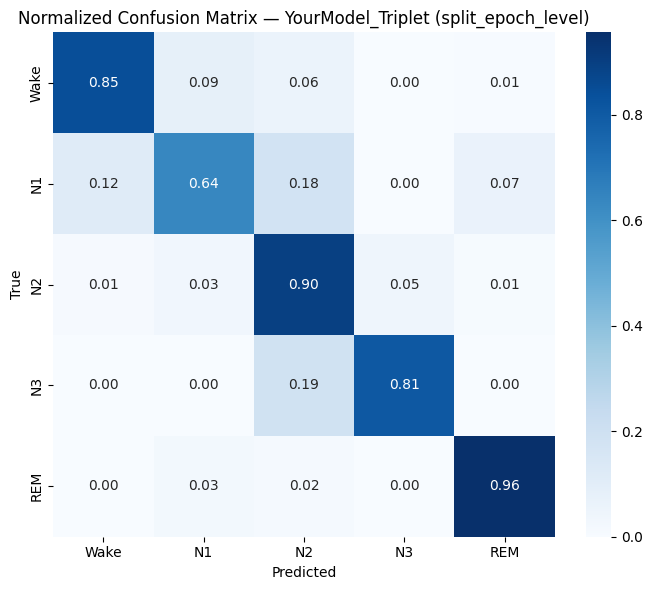

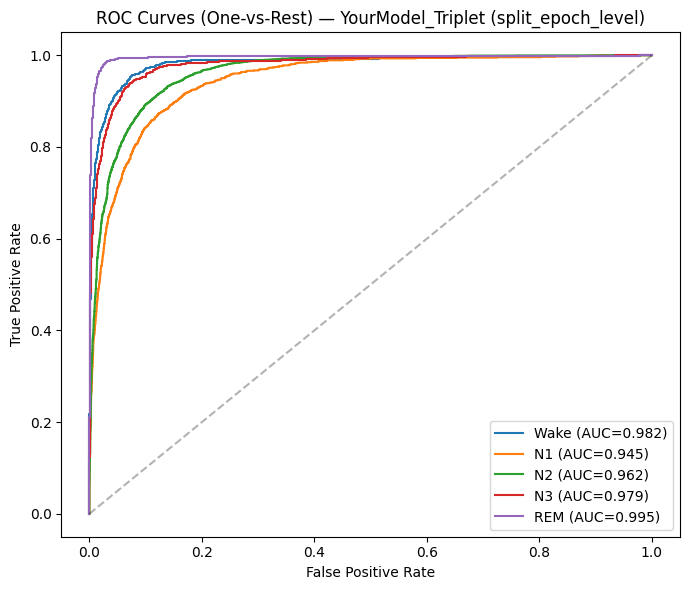

Loading val inputs for XAI:   0%|          | 0/293 [00:00<?, ?it/s]

In [ ]:
def full_triplet_report(result):
    model_name, split_col = result['model'], result['split']
    y_true, y_pred, probs_all = result['y_true'], result['y_pred'], result['probs']
    print(f"\n{'='*70}\nFULL REPORT: {model_name} | {split_col}\n{'='*70}")

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(7,6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Normalized Confusion Matrix — {model_name} ({split_col})")
    plt.tight_layout(); plt.show()

    y_true_bin = label_binarize(y_true, classes=list(range(5)))
    plt.figure(figsize=(7,6))
    for i, cname in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs_all[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'k--',alpha=0.3)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves (One-vs-Rest) — {model_name} ({split_col})")
    plt.legend(); plt.tight_layout(); plt.show()

    val_gen = CompleteTripletGenerator(result['val_df'], batch_size=32, shuffle=False)
    all_inputs = []
    for i in tqdm(range(len(val_gen)), desc="Loading val inputs for XAI"):
        Xb, _ = val_gen[i]
        all_inputs.append(Xb)
    X_val_all = np.concatenate(all_inputs, axis=0)

    best_model = tf.keras.models.load_model(result['ckpt_path'])
    channel_names = [f'Ch{i+1}' for i in range(X_val_all.shape[1])]

    def channel_occlusion_importance(model, X_subset, class_idx, batch_size=32):
        baseline_probs = model.predict(X_subset, batch_size=batch_size, verbose=0)[:, class_idx]
        drops = []
        for ch in range(X_subset.shape[1]):
            X_occ = X_subset.copy()
            X_occ[:, ch, :] = 0.0
            occ_probs = model.predict(X_occ, batch_size=batch_size, verbose=0)[:, class_idx]
            drops.append((baseline_probs - occ_probs).mean())
        return np.array(drops)

    stage_channel_results = {}
    for class_idx, class_name in enumerate(CLASS_NAMES):
        mask = (y_true == class_idx) & (y_pred == class_idx)
        X_subset = X_val_all[mask][:200]
        if len(X_subset) == 0:
            print(f"No correctly predicted samples for {class_name}")
            continue
        imp = channel_occlusion_importance(best_model, X_subset, class_idx)
        stage_channel_results[class_name] = imp
        most_prominent_idx = int(np.argmax(imp))
        print(f"{class_name}: most prominent channel = {channel_names[most_prominent_idx]} | score = {imp[most_prominent_idx]:.4f}")
        plt.figure(figsize=(10,4))
        plt.bar(channel_names, imp)
        plt.xticks(rotation=90)
        plt.title(f'Channel Prominence by Occlusion — {class_name} ({model_name}, {split_col})')
        plt.ylabel('Mean drop in target probability')
        plt.tight_layout(); plt.show()

    FS = EPOCH_LEN / 30.0
    band_defs = {
        'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8),
        'Alpha (8-12 Hz)': (8, 12), 'Sigma (12-16 Hz)': (12, 16),
        'Beta (16-30 Hz)': (16, 30),
    }
    def bandstop(X, low, high, fs=FS, order=4):
        b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='bandstop')
        return filtfilt(b, a, X, axis=-1)

    def band_occlusion_importance(model, X_subset, class_idx):
        baseline_probs = model.predict(X_subset, batch_size=32, verbose=0)[:, class_idx]
        results_ = {}
        for band_name, (low, high) in band_defs.items():
            X_muted = bandstop(X_subset, low, high)
            muted_probs = model.predict(X_muted, batch_size=32, verbose=0)[:, class_idx]
            results_[band_name] = (baseline_probs - muted_probs).mean()
        return results_

    stage_band_results = {}
    for class_idx, class_name in enumerate(CLASS_NAMES):
        mask = (y_true == class_idx) & (y_pred == class_idx)
        X_subset = X_val_all[mask][:200]
        if len(X_subset) == 0:
            continue
        band_imp = band_occlusion_importance(best_model, X_subset, class_idx)
        stage_band_results[class_name] = band_imp
        best_band = max(band_imp, key=band_imp.get)
        print(f"{class_name}: most prominent band = {best_band} | score = {band_imp[best_band]:.6f}")
        plt.figure(figsize=(8,4))
        plt.bar(list(band_imp.keys()), list(band_imp.values()))
        plt.xticks(rotation=20)
        plt.title(f'Frequency Band Prominence — {class_name} ({model_name}, {split_col})')
        plt.ylabel('Mean drop in target probability')
        plt.tight_layout(); plt.show()

    return {'stage_channel_results': stage_channel_results, 'stage_band_results': stage_band_results}

xai_epoch = full_triplet_report(result_epoch)

In [ ]:
print(tf.__version__)
print(master_df.shape)
print(triplet_df.shape)

2.20.0
(47090, 10)
(46928, 9)


In [ ]:
ckpt_path = os.path.join(MODEL_DIR, 'YourModel_Triplet_split_epoch_level.keras')
best_model = tf.keras.models.load_model(ckpt_path)

val_df = triplet_df[triplet_df['split_epoch_level'] == 'val'].reset_index(drop=True)
val_gen = CompleteTripletGenerator(val_df, batch_size=32, shuffle=False)

y_true, y_pred, all_probs = [], [], []
for i in tqdm(range(len(val_gen)), desc="Re-evaluating saved model"):
    Xb, yb = val_gen[i]
    preds = best_model.predict(Xb, verbose=0)
    all_probs.append(preds)
    y_true.extend(np.argmax(yb, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true, y_pred = np.array(y_true), np.array(y_pred)
probs_all = np.concatenate(all_probs, axis=0)

result_epoch = {
    'model': 'YourModel_Triplet', 'split': 'split_epoch_level',
    'accuracy': accuracy_score(y_true, y_pred),
    'ckpt_path': ckpt_path, 'y_true': y_true, 'y_pred': y_pred,
    'probs': probs_all, 'val_df': val_df
}
print("Reloaded val accuracy:", result_epoch['accuracy'])

Re-evaluating saved model:   0%|          | 0/293 [00:00<?, ?it/s]

Reloaded val accuracy: 0.8560153583617748


In [ ]:
def full_triplet_report(result):
    model_name, split_col = result['model'], result['split']
    y_true, y_pred, probs_all = result['y_true'], result['y_pred'], result['probs']
    print(f"\n{'='*70}\nFULL REPORT: {model_name} | {split_col}\n{'='*70}")

    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(7,6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Normalized Confusion Matrix — {model_name} ({split_col})")
    plt.tight_layout(); plt.show()

    y_true_bin = label_binarize(y_true, classes=list(range(5)))
    plt.figure(figsize=(7,6))
    for i, cname in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs_all[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'k--',alpha=0.3)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves (One-vs-Rest) — {model_name} ({split_col})")
    plt.legend(); plt.tight_layout(); plt.show()

    def load_triplet_batch(df_subset):
        X_batch = []
        for _, row in df_subset.iterrows():
            X_prev = np.load(row['filepath_prev']).astype(np.float32)
            X_curr = np.load(row['filepath_curr']).astype(np.float32)
            X_next = np.load(row['filepath_next']).astype(np.float32)
            X_context = np.concatenate([X_prev, X_curr, X_next], axis=-1)
            mean = X_context.mean(axis=1, keepdims=True)
            std = X_context.std(axis=1, keepdims=True)
            X_context = (X_context - mean) / (std + 1e-8)
            X_batch.append(X_context)
        return np.array(X_batch, dtype=np.float32)

    best_model = tf.keras.models.load_model(result['ckpt_path'])
    val_df_reset = result['val_df'].reset_index(drop=True)
    channel_names = [f'Ch{i+1}' for i in range(N_CHANNELS)]

    def channel_occlusion_importance(model, X_subset, class_idx, batch_size=32):
        baseline_probs = model.predict(X_subset, batch_size=batch_size, verbose=0)[:, class_idx]
        drops = []
        for ch in range(X_subset.shape[1]):
            X_occ = X_subset.copy()
            X_occ[:, ch, :] = 0.0
            occ_probs = model.predict(X_occ, batch_size=batch_size, verbose=0)[:, class_idx]
            drops.append((baseline_probs - occ_probs).mean())
            del X_occ
        return np.array(drops)

    stage_channel_results = {}
    for class_idx, class_name in enumerate(CLASS_NAMES):
        mask = (y_true == class_idx) & (y_pred == class_idx)
        idx_subset = np.where(mask)[0][:200]
        if len(idx_subset) == 0:
            print(f"No correctly predicted samples for {class_name}")
            continue
        X_subset = load_triplet_batch(val_df_reset.iloc[idx_subset])

        imp = channel_occlusion_importance(best_model, X_subset, class_idx)
        stage_channel_results[class_name] = imp
        most_prominent_idx = int(np.argmax(imp))
        print(f"{class_name}: most prominent channel = {channel_names[most_prominent_idx]} | score = {imp[most_prominent_idx]:.4f}")
        plt.figure(figsize=(10,4))
        plt.bar(channel_names, imp)
        plt.xticks(rotation=90)
        plt.title(f'Channel Prominence by Occlusion — {model_name} ({split_col})')
        plt.ylabel('Mean drop in target probability')
        plt.tight_layout(); plt.show()

        del X_subset
        gc.collect()

    FS = EPOCH_LEN / 30.0
    band_defs = {
        'Delta (0.5-4 Hz)': (0.5, 4), 'Theta (4-8 Hz)': (4, 8),
        'Alpha (8-12 Hz)': (8, 12), 'Sigma (12-16 Hz)': (12, 16),
        'Beta (16-30 Hz)': (16, 30),
    }
    def bandstop(X, low, high, fs=FS, order=4):
        b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='bandstop')
        return filtfilt(b, a, X, axis=-1)

    def band_occlusion_importance(model, X_subset, class_idx):
        baseline_probs = model.predict(X_subset, batch_size=32, verbose=0)[:, class_idx]
        results_ = {}
        for band_name, (low, high) in band_defs.items():
            X_muted = bandstop(X_subset, low, high)
            muted_probs = model.predict(X_muted, batch_size=32, verbose=0)[:, class_idx]
            results_[band_name] = (baseline_probs - muted_probs).mean()
            del X_muted
        return results_

    stage_band_results = {}
    for class_idx, class_name in enumerate(CLASS_NAMES):
        mask = (y_true == class_idx) & (y_pred == class_idx)
        idx_subset = np.where(mask)[0][:200]
        if len(idx_subset) == 0:
            continue
        X_subset = load_triplet_batch(val_df_reset.iloc[idx_subset])

        band_imp = band_occlusion_importance(best_model, X_subset, class_idx)
        stage_band_results[class_name] = band_imp
        best_band = max(band_imp, key=band_imp.get)
        print(f"{class_name}: most prominent band = {best_band} | score = {band_imp[best_band]:.6f}")
        plt.figure(figsize=(8,4))
        plt.bar(list(band_imp.keys()), list(band_imp.values()))
        plt.xticks(rotation=20)
        plt.title(f'Frequency Band Prominence — {model_name} ({split_col})')
        plt.ylabel('Mean drop in target probability')
        plt.tight_layout(); plt.show()

        del X_subset
        gc.collect()

    return {'stage_channel_results': stage_channel_results, 'stage_band_results': stage_band_results}


FULL REPORT: YourModel_Triplet | split_epoch_level
              precision    recall  f1-score   support

        Wake     0.8439    0.8479    0.8459      1256
          N1     0.7208    0.6384    0.6771      1181
          N2     0.8814    0.8975    0.8894      4381
          N3     0.8203    0.8105    0.8154      1177
         REM     0.9148    0.9566    0.9352      1381

    accuracy                         0.8560      9376
   macro avg     0.8363    0.8302    0.8326      9376
weighted avg     0.8534    0.8560    0.8543      9376



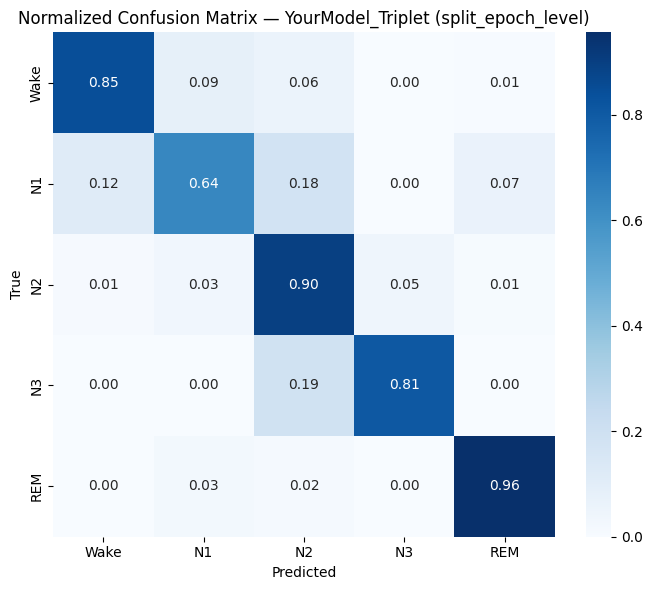

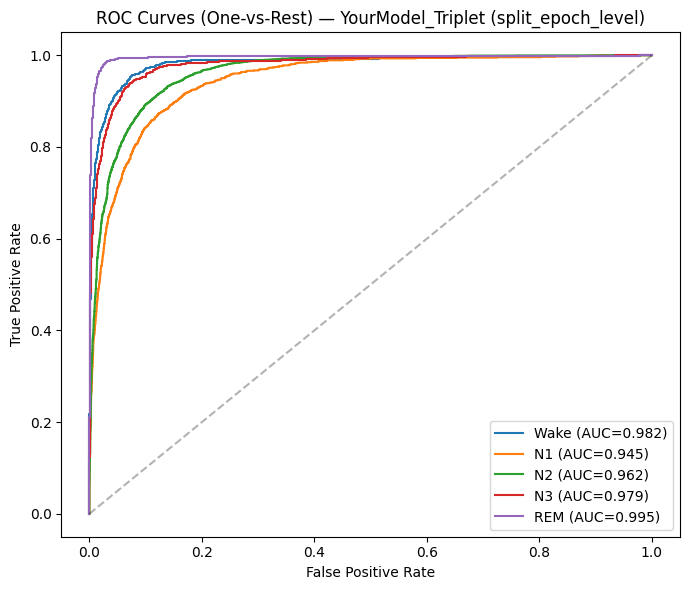

Wake: most prominent channel = Ch14 | score = 0.0575


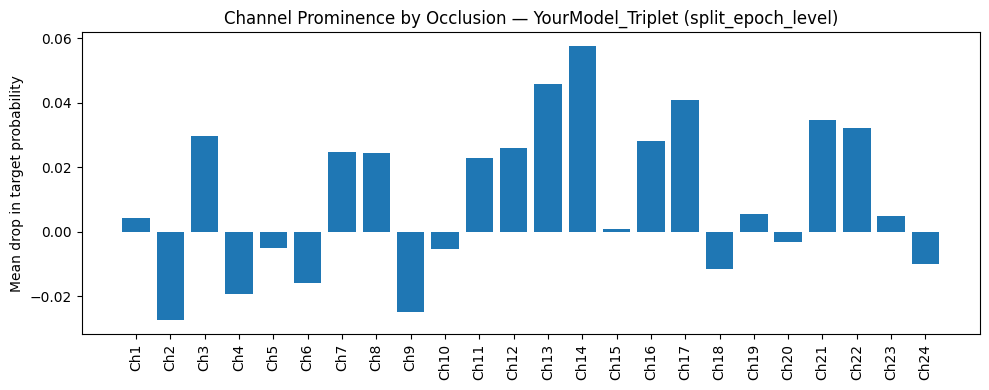

N1: most prominent channel = Ch10 | score = 0.1552


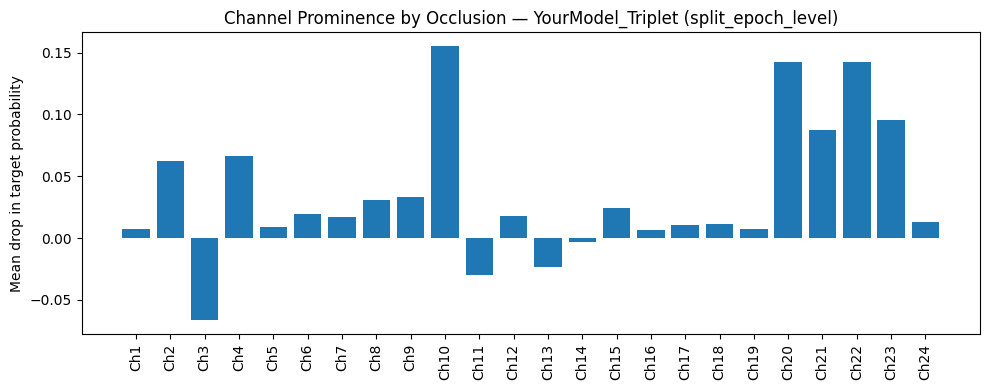

N2: most prominent channel = Ch13 | score = 0.0556


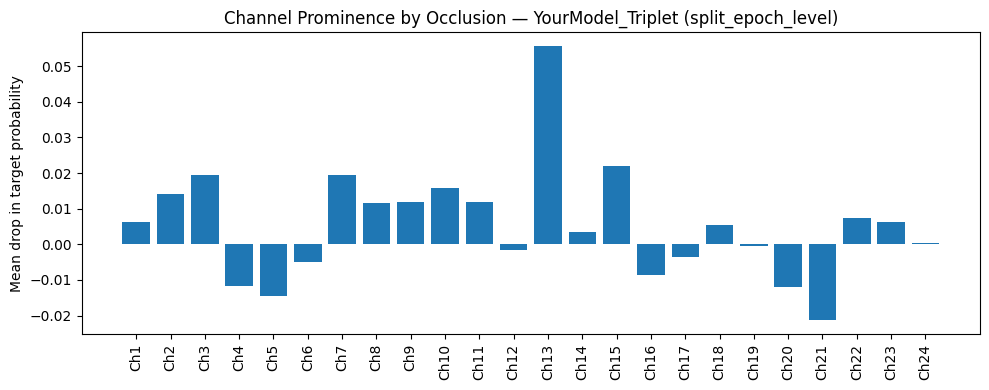

N3: most prominent channel = Ch16 | score = 0.0965


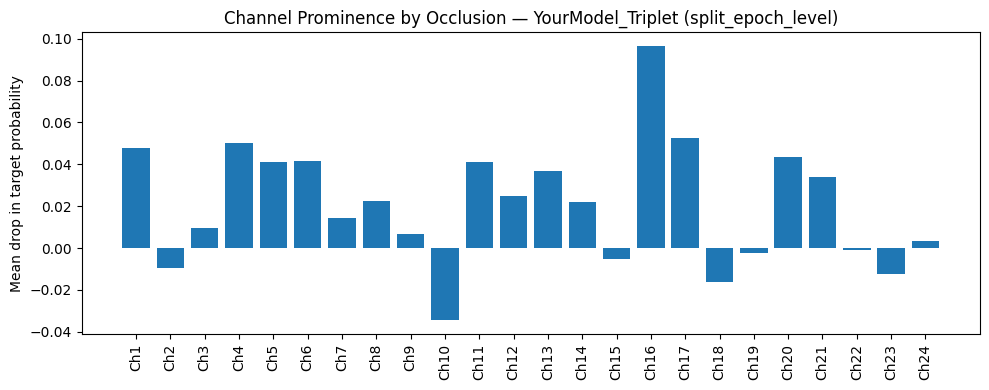

REM: most prominent channel = Ch20 | score = 0.0424


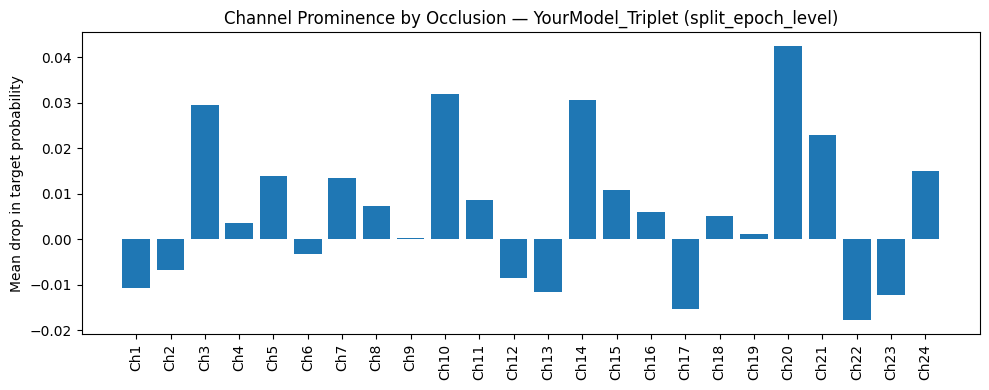

Wake: most prominent band = Alpha (8-12 Hz) | score = 0.257240


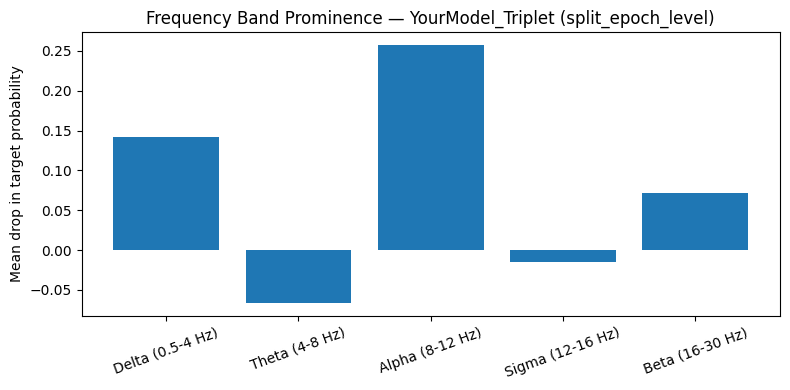

N1: most prominent band = Theta (4-8 Hz) | score = 0.199301


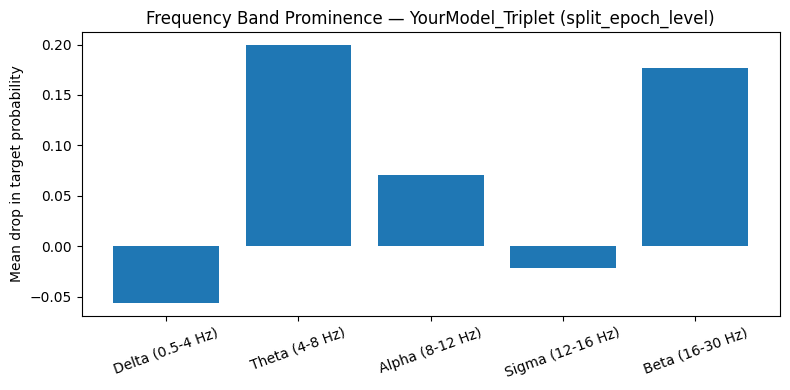

N2: most prominent band = Delta (0.5-4 Hz) | score = 0.589629


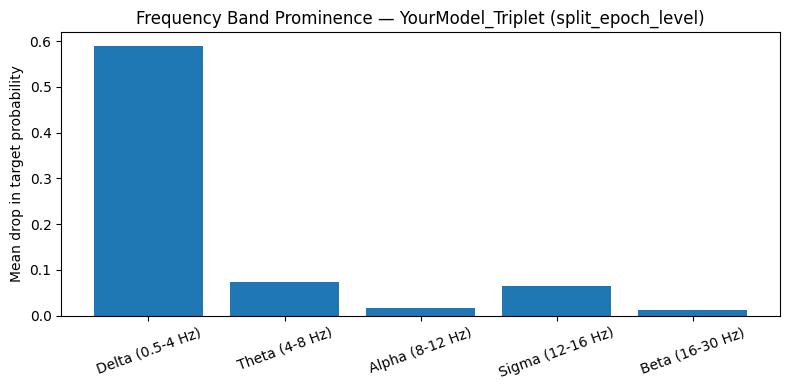

N3: most prominent band = Delta (0.5-4 Hz) | score = 0.843502


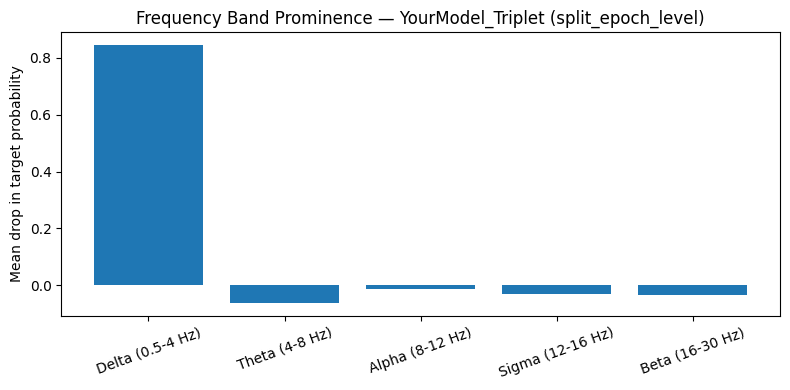

REM: most prominent band = Delta (0.5-4 Hz) | score = 0.334125


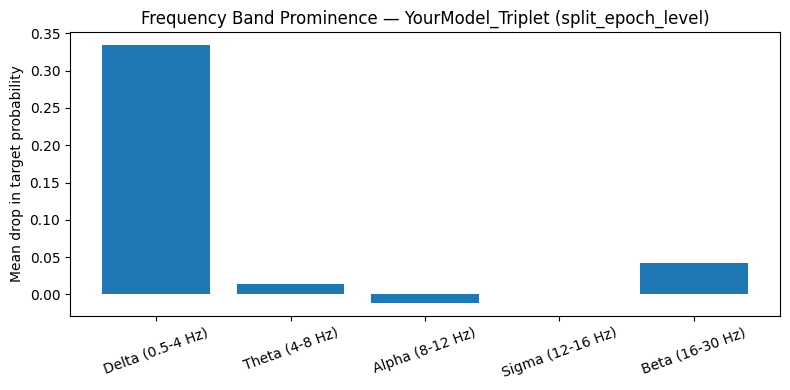

In [ ]:
xai_epoch = full_triplet_report(result_epoch)

In [ ]:
os.makedirs(os.path.join(MODEL_DIR, 'figures_epoch_level'), exist_ok=True)

In [ ]:
plt.savefig(os.path.join(MODEL_DIR, 'figures_epoch_level', f'confusion_matrix.png'), dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>